In [1]:
from eregion.tasks import ImageCreator, AssembleFocalPlane
from eregion.tasks.custom import guess_image_type_from_filename_DEIMOS, load_image_fits_DEIMOS
from eregion.tasks.calibration import MasterBias, CalibrationResult
from eregion.tasks.preprocessing import BiasSubtraction, ScanSubtraction, SigmaClipMasking

import numpy as np
import matplotlib.pyplot as plt
import os
import glob2
import importlib

# Example: DEIMOS science focal plane characterization: PTC

In [2]:
basepath = '/Users/yashvi/Desktop/Detector Characterization Tools/DTU_dettest/DTU_fullfp_bringup/PTC/SCI'
runid = '20260718*'
rawpath = glob2.glob(os.path.join(basepath, runid))[0]
outpath = rawpath.replace('/DTU_dettest/','/DTU_detreduce/')
if not os.path.exists(outpath):
    os.makedirs(outpath)

### Calproc

In [4]:
# Load bias images
creator = ImageCreator(detector_config = '../src/eregion/configs/detectors/deimos_sci.yaml')
res = creator.run(input_source = os.path.join(rawpath,'*bias*.fits'),
                  identifier_func = guess_image_type_from_filename_DEIMOS,
                  fileloader_func = load_image_fits_DEIMOS,
                  data_on_demand = True)

# subtract overscan
oscan_sub = ScanSubtraction(which_scan='serial_overscan', method='median_by_axis', trim_start=6)
res = oscan_sub.run(images=res.data)
#
cr_mask = SigmaClipMasking(sigma_clip_args={'sigma_lower':5.0, 'sigma_upper':5.0})
res = cr_mask.run(images=res.data)


2026-09-14 20:08:20,386 - DetectorConfig - INFO - Config loaded from file '../src/eregion/configs/detectors/deimos_sci.yaml'
2026-09-14 20:08:20,386 - DetectorConfig - INFO - Config loaded from file '../src/eregion/configs/detectors/deimos_sci.yaml'
2026-09-14 20:08:20,387 - image_creator - INFO - Item /Users/yashvi/Desktop/Detector Characterization Tools/DTU_dettest/DTU_fullfp_bringup/PTC/SCI/20260718-001407/*bias*.fits is a glob pattern
2026-09-14 20:08:20,387 - image_creator - INFO - Item /Users/yashvi/Desktop/Detector Characterization Tools/DTU_dettest/DTU_fullfp_bringup/PTC/SCI/20260718-001407/*bias*.fits is a glob pattern
2026-09-14 20:08:27,462 - ScanSubtraction - INFO - Setting method 'median_by_axis' for task ScanSubtraction.
2026-09-14 20:08:27,462 - ScanSubtraction - INFO - Setting method 'median_by_axis' for task ScanSubtraction.
/Users/yashvi/Desktop/Detector Characterization Tools/eregion/.venv/lib/python3.13/site-packages/joblib/externals/loky/process_executor.py:782: Us

In [5]:
# make master bias
master_bias_task = MasterBias(method='median', mask_key='sigma_clip_mask')
mb_res = master_bias_task.run(images=res.data)

2026-09-14 20:09:33,124 - MasterBias - INFO - Setting method 'median' for task MasterBias.
2026-09-14 20:09:35,105 - MasterBias - INFO - Created master calibration frame for det_id: det_1, type: {'type': 'master_bias', 'exptime': 0.0, 'obstime': '2026-07-18T001412.976', 'seqnum': 0, 'led': 'GREEN', 'backbias': '-50.0', 'serial_overscan_subtracted': True, 'bad_pixel_masked': True}
2026-09-14 20:09:36,727 - MasterBias - INFO - Created master calibration frame for det_id: det_2, type: {'type': 'master_bias', 'exptime': 0.0, 'obstime': '2026-07-18T001412.976', 'seqnum': 0, 'led': 'GREEN', 'backbias': '-50.0', 'serial_overscan_subtracted': True, 'bad_pixel_masked': True}
2026-09-14 20:09:38,350 - MasterBias - INFO - Created master calibration frame for det_id: det_3, type: {'type': 'master_bias', 'exptime': 0.0, 'obstime': '2026-07-18T001412.976', 'seqnum': 0, 'led': 'GREEN', 'backbias': '-50.0', 'serial_overscan_subtracted': True, 'bad_pixel_masked': True}
2026-09-14 20:09:40,386 - MasterB

<Axes: xlabel='x', ylabel='y'>

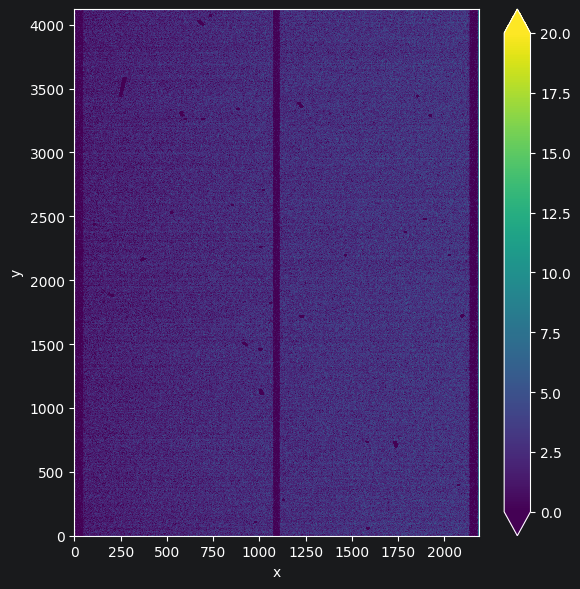

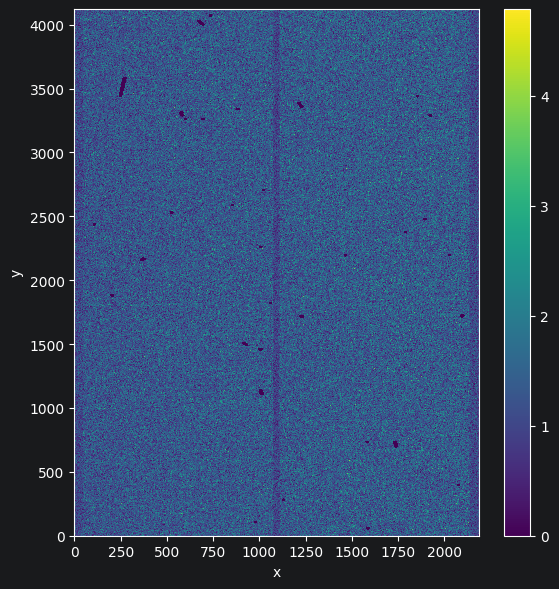

In [6]:
mb_res.master_bias[0].show(with_mask=True, data_var='data', vmin=0, vmax=20)
mb_res.master_bias[0].show(with_mask=True, data_var='std')


In [7]:
# cleanup memory
del res
# save master bias result obj
mb_res.save(outpath)

/Users/yashvi/Desktop/Detector Characterization Tools/eregion/src/eregion/tasks/imagegen.py:52: UserWarning: ImageBundle for attribute data is empty. Not saving.
  warnings.warn(f"ImageBundle for attribute {attr} is empty. Not saving.")
/Users/yashvi/Desktop/Detector Characterization Tools/eregion/src/eregion/tasks/imagegen.py:52: UserWarning: ImageBundle for attribute master_dark is empty. Not saving.
  warnings.warn(f"ImageBundle for attribute {attr} is empty. Not saving.")
/Users/yashvi/Desktop/Detector Characterization Tools/eregion/src/eregion/tasks/imagegen.py:52: UserWarning: ImageBundle for attribute master_flat is empty. Not saving.
  warnings.warn(f"ImageBundle for attribute {attr} is empty. Not saving.")
/Users/yashvi/Desktop/Detector Characterization Tools/eregion/src/eregion/tasks/imagegen.py:52: UserWarning: ImageBundle for attribute master_lamp is empty. Not saving.
  warnings.warn(f"ImageBundle for attribute {attr} is empty. Not saving.")


In [8]:
# load master bias result obj
mb_res = CalibrationResult.load(outpath)
mb_res.master_bias

,type,exptime,obstime,seqnum,led,backbias,serial_overscan_subtracted,bad_pixel_masked,det_id,filename,object
0,master_bias,0.0,2026-07-18T001412.976,0,GREEN,-50.0,True,True,det_1,/Users/yashvi/Desktop/Detector Characterizatio...,<eregion.datamodels.image.DetImage object at 0...
1,master_bias,0.0,2026-07-18T001412.976,0,GREEN,-50.0,True,True,det_2,/Users/yashvi/Desktop/Detector Characterizatio...,<eregion.datamodels.image.DetImage object at 0...
2,master_bias,0.0,2026-07-18T001412.976,0,GREEN,-50.0,True,True,det_3,/Users/yashvi/Desktop/Detector Characterizatio...,<eregion.datamodels.image.DetImage object at 0...
3,master_bias,0.0,2026-07-18T001412.976,0,GREEN,-50.0,True,True,det_4,/Users/yashvi/Desktop/Detector Characterizatio...,<eregion.datamodels.image.DetImage object at 0...
4,master_bias,0.0,2026-07-18T001412.976,0,GREEN,-50.0,True,True,det_5,/Users/yashvi/Desktop/Detector Characterizatio...,<eregion.datamodels.image.DetImage object at 0...
5,master_bias,0.0,2026-07-18T001412.976,0,GREEN,-50.0,True,True,det_6,/Users/yashvi/Desktop/Detector Characterizatio...,<eregion.datamodels.image.DetImage object at 0...
6,master_bias,0.0,2026-07-18T001412.976,0,GREEN,-50.0,True,True,det_7,/Users/yashvi/Desktop/Detector Characterizatio...,<eregion.datamodels.image.DetImage object at 0...
7,master_bias,0.0,2026-07-18T001412.976,0,GREEN,-50.0,True,True,det_8,/Users/yashvi/Desktop/Detector Characterizatio...,<eregion.datamodels.image.DetImage object at 0...


Make focal plane image. `AssembleFocalPlane` task can take ImageBundle and group them into sets of focal plane images based on the list of columns that uniquely identify an exposure.

In [9]:
def plot_focal_plane(bundle, grouping_columns=['type', 'exptime', 'seqnum'], zscale=False, **kwargs):
    fp_task = AssembleFocalPlane(num_detectors=8)
    fp_res = fp_task.run(from_images=bundle, groupby_keys=grouping_columns)
    img = fp_res.data[0]
    with_mask = kwargs.pop('with_mask', False)
    mask_key = kwargs.pop('mask_key', 'sigma_clip_mask')
    data_var = kwargs.pop('data_var', 'data')
    textcolor = kwargs.pop('textcolor', 'yellow')
    if zscale:
        vmin, vmax = np.percentile(img._data[data_var].values, [5, 95])
    else:
        vmin, vmax = kwargs.pop('vmin',None), kwargs.pop('vmax',None)
    img.show(show_det_id=True, with_mask=with_mask, mask_key=mask_key, data_var=data_var, textcolor=textcolor, vmin=vmin, vmax=vmax, **kwargs)
    return fp_res.data

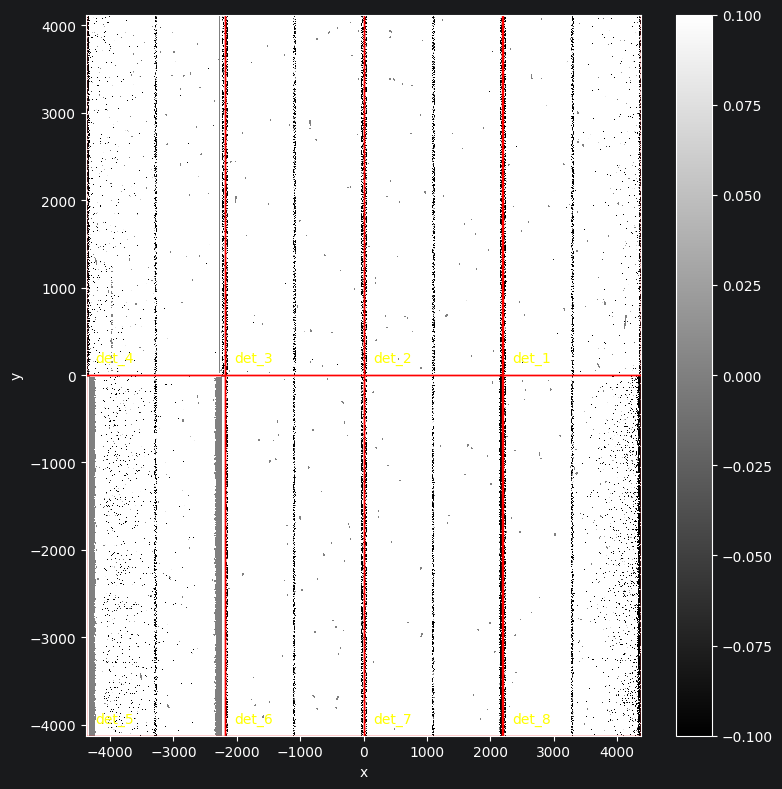

In [15]:
fpbundle = plot_focal_plane(mb_res.master_bias, zscale=True, cmap='gray', data_var='data', with_mask=True)

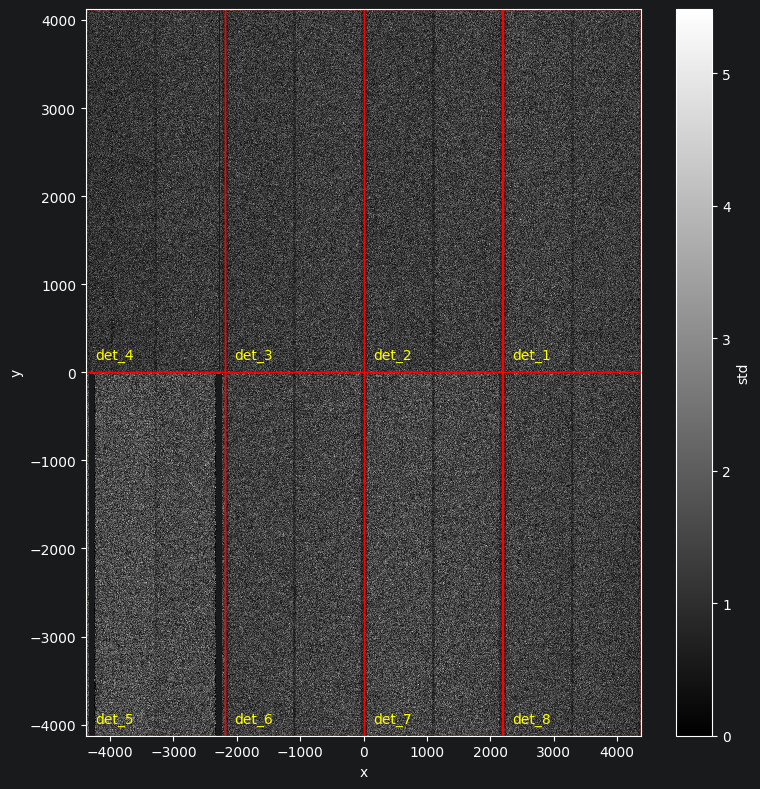

In [12]:
_ = plot_focal_plane(mb_res.master_bias, zscale=False, cmap='gray', data_var='std')

In [13]:
for img in mb_res.master_bias:
    for out in img.outputs.values():
        data, _ = out.get_image_region(data_var='all')
        print(img.id, out.id)
        print(data['data'].min(), data['data'].max())
        print(data['std'].min(), data['std'].max())
        print('--------')

det_1 E
<xarray.DataArray 'data' ()> Size: 8B
array(-2.15457153) <xarray.DataArray 'data' ()> Size: 8B
array(6.91374969)
<xarray.DataArray 'std' ()> Size: 8B
array(0.01530999) <xarray.DataArray 'std' ()> Size: 8B
array(4.22572964)
--------
det_1 F
<xarray.DataArray 'data' ()> Size: 8B
array(-2.24803925) <xarray.DataArray 'data' ()> Size: 8B
array(7.7013092)
<xarray.DataArray 'std' ()> Size: 8B
array(0.02154052) <xarray.DataArray 'std' ()> Size: 8B
array(4.78713034)
--------
det_2 E
<xarray.DataArray 'data' ()> Size: 8B
array(-1.18572998) <xarray.DataArray 'data' ()> Size: 8B
array(8.04510498)
<xarray.DataArray 'std' ()> Size: 8B
array(0.02250731) <xarray.DataArray 'std' ()> Size: 8B
array(4.3539464)
--------
det_2 F
<xarray.DataArray 'data' ()> Size: 8B
array(-1.28666687) <xarray.DataArray 'data' ()> Size: 8B
array(7.9750824)
<xarray.DataArray 'std' ()> Size: 8B
array(0.02461827) <xarray.DataArray 'std' ()> Size: 8B
array(4.08128465)
--------
det_3 E
<xarray.DataArray 'data' ()> Size: 

### Preproc

Sanity checks for each step

In [16]:
def quick_plot(img):
    vmin, vmax = np.percentile(img.data.values, [5, 95])
    img.show(cmap='gray', vmin=vmin, vmax=vmax, origin='lower')

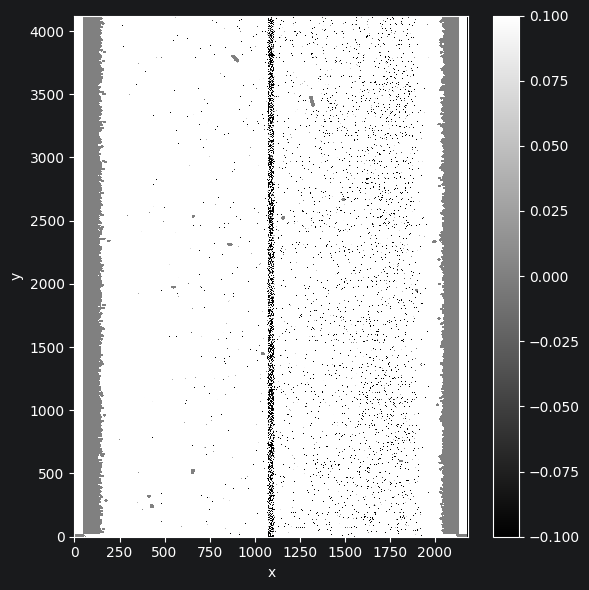

In [17]:
# plot master bias
quick_plot(mb_res.master_bias[4])

In [18]:
## Loading a pair at an exptime
creator = ImageCreator(detector_config='../src/eregion/configs/detectors/deimos_sci.yaml', max_batch_size=2)

flpair = creator.run(input_source='/Users/yashvi/Desktop/Detector Characterization Tools/DTU_dettest/DTU_fullfp_bringup/PTC/SCI/20260718*/*SCI_*_flat_0.032*.fits',
                  identifier_func=guess_image_type_from_filename_DEIMOS,
                  fileloader_func=load_image_fits_DEIMOS,
                  data_on_demand=True)
flpair.data

2026-09-14 20:14:52,413 - DetectorConfig - INFO - Config loaded from file '../src/eregion/configs/detectors/deimos_sci.yaml'
2026-09-14 20:14:52,413 - DetectorConfig - INFO - Config loaded from file '../src/eregion/configs/detectors/deimos_sci.yaml'
2026-09-14 20:14:52,413 - DetectorConfig - INFO - Config loaded from file '../src/eregion/configs/detectors/deimos_sci.yaml'
2026-09-14 20:14:52,416 - image_creator - INFO - Item /Users/yashvi/Desktop/Detector Characterization Tools/DTU_dettest/DTU_fullfp_bringup/PTC/SCI/20260718*/*SCI_*_flat_0.032*.fits is a glob pattern
2026-09-14 20:14:52,416 - image_creator - INFO - Item /Users/yashvi/Desktop/Detector Characterization Tools/DTU_dettest/DTU_fullfp_bringup/PTC/SCI/20260718*/*SCI_*_flat_0.032*.fits is a glob pattern
2026-09-14 20:14:52,416 - image_creator - INFO - Item /Users/yashvi/Desktop/Detector Characterization Tools/DTU_dettest/DTU_fullfp_bringup/PTC/SCI/20260718*/*SCI_*_flat_0.032*.fits is a glob pattern


,type,exptime,obstime,seqnum,led,backbias,det_id,filename,object
0,flat,0.032,2026-07-18T040300.129,0,GREEN,-50.0,det_1,/Users/yashvi/Desktop/Detector Characterizatio...,<eregion.datamodels.image.DetImage object at 0...
1,flat,0.032,2026-07-18T040427.627,1,GREEN,-50.0,det_1,/Users/yashvi/Desktop/Detector Characterizatio...,<eregion.datamodels.image.DetImage object at 0...
2,flat,0.032,2026-07-18T040300.129,0,GREEN,-50.0,det_2,/Users/yashvi/Desktop/Detector Characterizatio...,<eregion.datamodels.image.DetImage object at 0...
3,flat,0.032,2026-07-18T040427.627,1,GREEN,-50.0,det_2,/Users/yashvi/Desktop/Detector Characterizatio...,<eregion.datamodels.image.DetImage object at 0...
4,flat,0.032,2026-07-18T040300.129,0,GREEN,-50.0,det_3,/Users/yashvi/Desktop/Detector Characterizatio...,<eregion.datamodels.image.DetImage object at 0...
5,flat,0.032,2026-07-18T040427.627,1,GREEN,-50.0,det_3,/Users/yashvi/Desktop/Detector Characterizatio...,<eregion.datamodels.image.DetImage object at 0...
6,flat,0.032,2026-07-18T040300.129,0,GREEN,-50.0,det_4,/Users/yashvi/Desktop/Detector Characterizatio...,<eregion.datamodels.image.DetImage object at 0...
7,flat,0.032,2026-07-18T040427.627,1,GREEN,-50.0,det_4,/Users/yashvi/Desktop/Detector Characterizatio...,<eregion.datamodels.image.DetImage object at 0...
8,flat,0.032,2026-07-18T040300.129,0,GREEN,-50.0,det_5,/Users/yashvi/Desktop/Detector Characterizatio...,<eregion.datamodels.image.DetImage object at 0...
9,flat,0.032,2026-07-18T040427.627,1,GREEN,-50.0,det_5,/Users/yashvi/Desktop/Detector Characterizatio...,<eregion.datamodels.image.DetImage object at 0...


,object,filename,type,exptime,obstime,seqnum,led,backbias
0,<eregion.datamodels.focalplaneimage.FocalPlane...,None,flat,0.032,2026-07-18T040300.129,0,GREEN,-50.0
1,<eregion.datamodels.focalplaneimage.FocalPlane...,None,flat,0.032,2026-07-18T040427.627,1,GREEN,-50.0


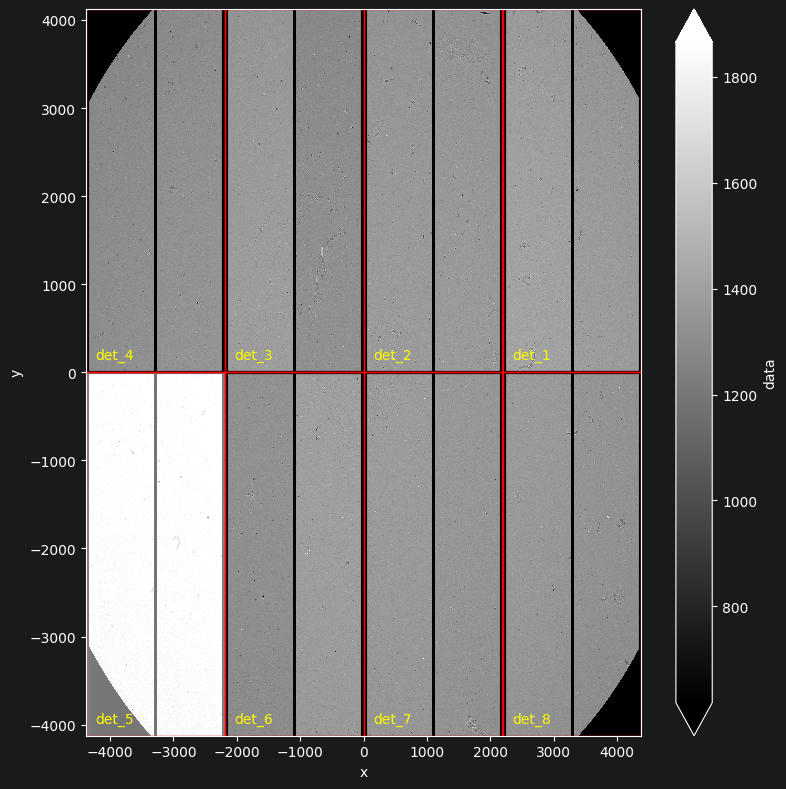

In [11]:
# quick_plot(flpair.data[0])
plot_focal_plane(flpair.data, zscale=True, cmap='gray')

In [19]:
# Do overscan sub
oscan_sub = ScanSubtraction(which_scan='serial_overscan', method='median_by_axis', trim_start=6)
flpair = oscan_sub.run(images=flpair.data)

2026-09-14 20:15:07,446 - ScanSubtraction - INFO - Setting method 'median_by_axis' for task ScanSubtraction.
2026-09-14 20:15:07,446 - ScanSubtraction - INFO - Setting method 'median_by_axis' for task ScanSubtraction.
2026-09-14 20:15:07,446 - ScanSubtraction - INFO - Setting method 'median_by_axis' for task ScanSubtraction.
/Users/yashvi/Desktop/Detector Characterization Tools/eregion/.venv/lib/python3.13/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


,object,filename,type,exptime,obstime,seqnum,led,backbias,serial_overscan_subtracted
0,<eregion.datamodels.focalplaneimage.FocalPlane...,None,flat,0.032,2026-07-18T040300.129,0,GREEN,-50.0,True
1,<eregion.datamodels.focalplaneimage.FocalPlane...,None,flat,0.032,2026-07-18T040427.627,1,GREEN,-50.0,True


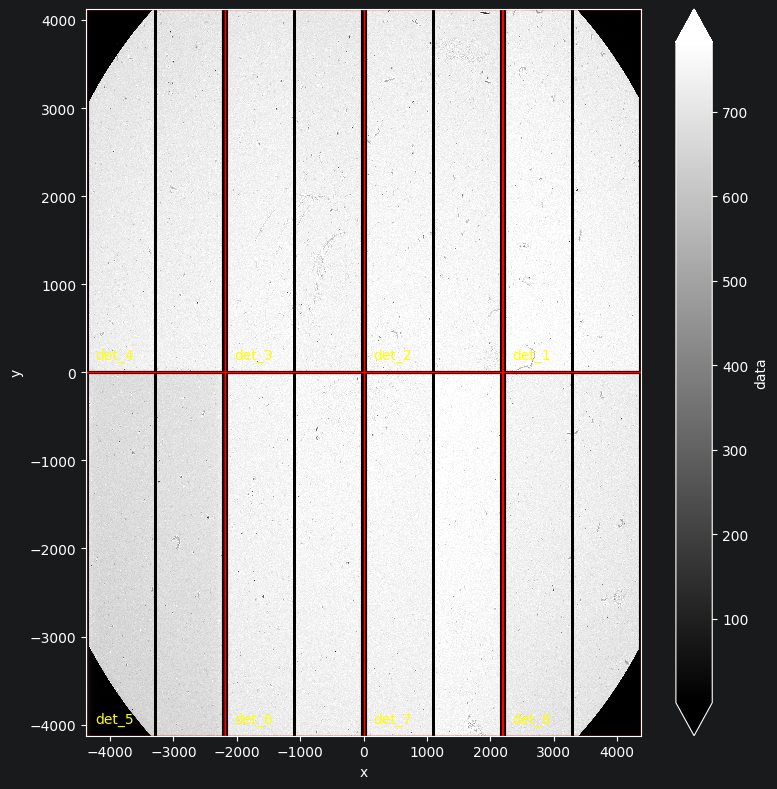

In [13]:
# quick_plot(after_osub.data[0])
plot_focal_plane(flpair.data, zscale=True, cmap='gray')

In [20]:
# Do sigma clip
from copy import deepcopy
cr_mask = SigmaClipMasking(sigma_clip_args={'sigma_lower':5.0, 'sigma_upper':5.0}) # set n_jobs=1 to be able to debug in pycharm inside parallelized jobs
flpair = cr_mask.run(images=flpair.data)

2026-09-14 20:15:16,564 - sigma_clip_masking - INFO - Setting method 'ccd' for task sigma_clip_masking.
2026-09-14 20:15:16,564 - sigma_clip_masking - INFO - Setting method 'ccd' for task sigma_clip_masking.
2026-09-14 20:15:16,564 - sigma_clip_masking - INFO - Setting method 'ccd' for task sigma_clip_masking.


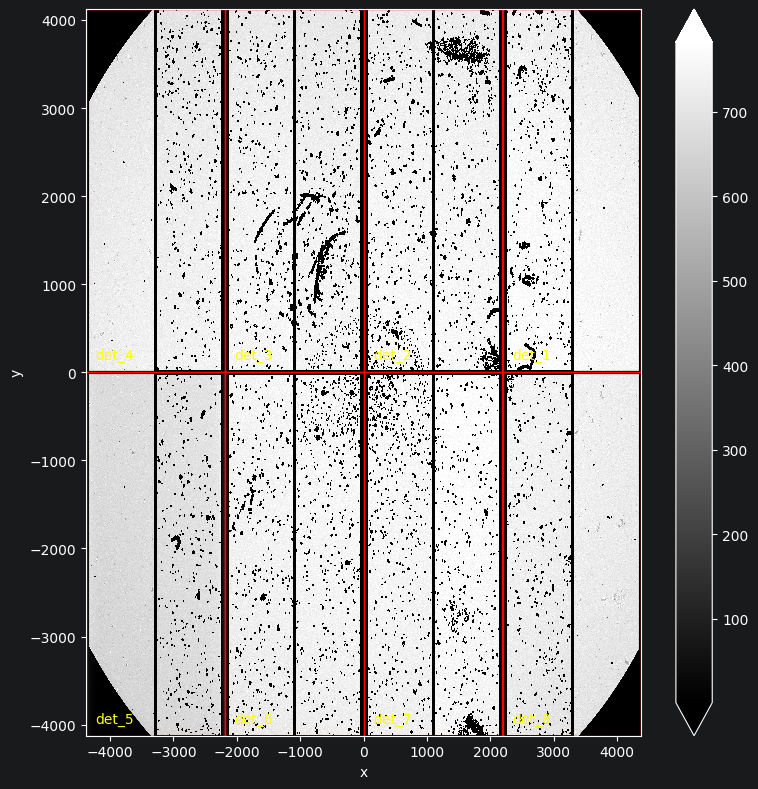

In [21]:
fpims = plot_focal_plane(flpair.data, zscale=True, with_mask=True, cmap='gray')

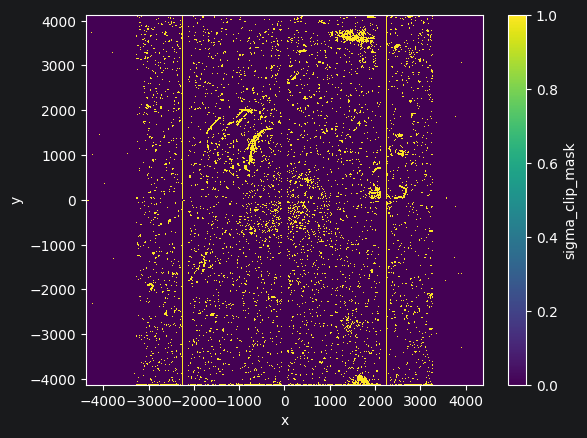

In [22]:
fpims[0].masks['sigma_clip_mask'].plot.imshow()

In [23]:
# Do bias sub
bias_sub = BiasSubtraction(only_image_area=True)
flpair = bias_sub.run(images=flpair.data, master_bias=mb_res.master_bias)

/Users/yashvi/Desktop/Detector Characterization Tools/eregion/.venv/lib/python3.13/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
/Users/yashvi/Desktop/Detector Characterization Tools/eregion/.venv/lib/python3.13/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


,object,filename,type,exptime,obstime,seqnum,led,backbias,serial_overscan_subtracted,bad_pixel_masked,bias_subtracted
0,<eregion.datamodels.focalplaneimage.FocalPlane...,None,flat,0.032,2026-07-18T040300.129,0,GREEN,-50.0,True,True,True
1,<eregion.datamodels.focalplaneimage.FocalPlane...,None,flat,0.032,2026-07-18T040427.627,1,GREEN,-50.0,True,True,True


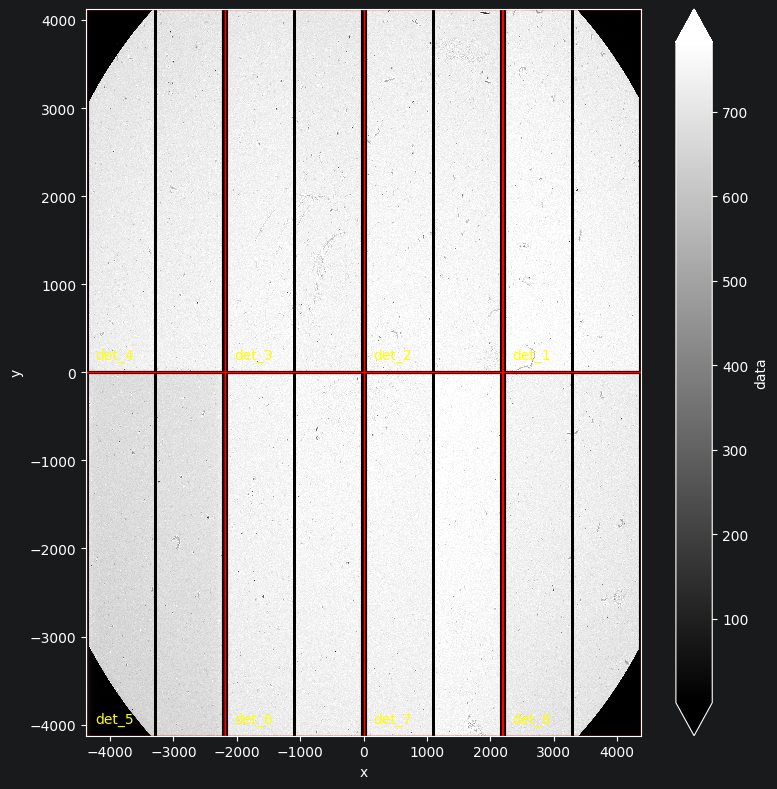

In [24]:
# quick_plot(after_bs.data[0])
plot_focal_plane(flpair.data, zscale=True, cmap='gray')

In [25]:
# Do PTC
import eregion.tasks.ptc as ptc
import eregion
importlib.reload(eregion)
importlib.reload(ptc)

ptc_task = ptc.PTC()
pres = ptc_task.run(images=flpair.data)

2026-09-14 20:18:48,862 - PTC - INFO - Processed 16 flats, upto exposure time 0.032


In [26]:
pres.ptc_table

,exptime,det_id,output,n_masked_0,mean_0,median_0,std_0,mad_0,skew_0,kurt_0,...,lastllel_median_0-1,lastllel_std_0-1,lastllel_mad_0-1,lastser_mean_0-1,lastser_median_0-1,lastser_std_0-1,lastser_mad_0-1,mean,median,std
0,0.032,det_1,E,1848,663.750765,741.323807,231.150484,28.095760,-2.460466,4.197508,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,663.772885,741.330181,15.712558
1,0.032,det_1,F,363550,759.028894,759.647850,24.715136,24.580179,-0.103053,0.125921,...,NaN,NaN,NaN,0.015770,0.156513,23.706017,23.887234,759.032229,759.641949,16.988272
2,0.032,det_2,E,484913,746.252157,746.798347,23.286446,22.940371,-0.125882,0.236066,...,1.583984,15.662826,16.899111,-0.062167,-0.538212,22.707582,22.450143,746.249455,746.794979,16.318244
3,0.032,det_2,F,371799,747.580746,747.854988,23.004927,22.910227,-0.038679,0.125357,...,0.710846,15.458184,14.761265,NaN,NaN,NaN,NaN,747.593531,747.866890,16.355173
4,0.032,det_3,E,481426,735.270987,735.342308,23.522743,23.317696,0.023049,0.226964,...,0.334602,14.681994,14.833352,-0.294093,-0.090504,22.171563,22.112120,735.293676,735.364658,15.935510
5,0.032,det_3,F,318983,739.658435,740.013641,22.964426,22.848274,-0.044881,0.147577,...,-0.771683,15.359831,15.864382,-0.209862,-0.464027,22.373414,21.831123,739.669292,740.022472,15.870627
6,0.032,det_4,E,275899,725.347577,725.964989,23.188254,23.196811,-0.107727,0.088674,...,-0.413437,14.980296,15.283295,-0.073176,-0.139519,22.420026,22.475984,725.358419,725.976006,15.865117
7,0.032,det_4,F,2823,635.401017,715.038925,229.466911,26.124903,-2.358082,3.677972,...,0.999542,15.054473,14.354893,NaN,NaN,NaN,NaN,635.363729,715.035049,14.506073
8,0.032,det_5,E,1421,595.514059,664.483200,206.145085,23.309370,-2.468113,4.215440,...,1.358078,14.759150,14.488865,NaN,NaN,NaN,NaN,595.500815,664.501049,14.008953
9,0.032,det_5,F,276248,682.081136,682.106705,20.500241,20.303179,0.009921,0.121660,...,0.469025,14.181562,15.029276,0.364682,0.649120,20.437895,20.613800,682.079273,682.100136,14.532101


In [27]:
# save to fits
pres.save(outpath)

In [28]:
# load from fits
pres = ptc.PTCResult.load(outpath)
pres.ptc_table

,exptime,det_id,output,n_masked_0,mean_0,median_0,std_0,mad_0,skew_0,kurt_0,...,lastllel_median_0-1,lastllel_std_0-1,lastllel_mad_0-1,lastser_mean_0-1,lastser_median_0-1,lastser_std_0-1,lastser_mad_0-1,mean,median,std
0,0.032,det_1,E,1848,663.750765,741.323807,231.150484,28.095760,-2.460466,4.197508,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,663.772885,741.330181,15.712558
1,0.032,det_1,F,363550,759.028894,759.647850,24.715136,24.580179,-0.103053,0.125921,...,NaN,NaN,NaN,0.015770,0.156513,23.706017,23.887234,759.032229,759.641949,16.988272
2,0.032,det_2,E,484913,746.252157,746.798347,23.286446,22.940371,-0.125882,0.236066,...,1.583984,15.662826,16.899111,-0.062167,-0.538212,22.707582,22.450143,746.249455,746.794979,16.318244
3,0.032,det_2,F,371799,747.580746,747.854988,23.004927,22.910227,-0.038679,0.125357,...,0.710846,15.458184,14.761265,NaN,NaN,NaN,NaN,747.593531,747.866890,16.355173
4,0.032,det_3,E,481426,735.270987,735.342308,23.522743,23.317696,0.023049,0.226964,...,0.334602,14.681994,14.833352,-0.294093,-0.090504,22.171563,22.112120,735.293676,735.364658,15.935510
5,0.032,det_3,F,318983,739.658435,740.013641,22.964426,22.848274,-0.044881,0.147577,...,-0.771683,15.359831,15.864382,-0.209862,-0.464027,22.373414,21.831123,739.669292,740.022472,15.870627
6,0.032,det_4,E,275899,725.347577,725.964989,23.188254,23.196811,-0.107727,0.088674,...,-0.413437,14.980296,15.283295,-0.073176,-0.139519,22.420026,22.475984,725.358419,725.976006,15.865117
7,0.032,det_4,F,2823,635.401017,715.038925,229.466911,26.124903,-2.358082,3.677972,...,0.999542,15.054473,14.354893,NaN,NaN,NaN,NaN,635.363729,715.035049,14.506073
8,0.032,det_5,E,1421,595.514059,664.483200,206.145085,23.309370,-2.468113,4.215440,...,1.358078,14.759150,14.488865,NaN,NaN,NaN,NaN,595.500815,664.501049,14.008953
9,0.032,det_5,F,276248,682.081136,682.106705,20.500241,20.303179,0.009921,0.121660,...,0.469025,14.181562,15.029276,0.364682,0.649120,20.437895,20.613800,682.079273,682.100136,14.532101


For everything together, check out deimos_sci_testing.py